1. Setup

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

2. Data Loading

In [2]:
# Cell 2: Load Data
from google.colab import drive
drive.mount('/content/drive')
# Cell 3: Merge Data
client_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Client.csv')
record_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Record.csv')

# Merge on Customer_ID to build 100,000 x 100 matrix
df = pd.merge(client_df, record_df, on='Customer_ID', how='inner')
print(f"Dataset Shape: {df.shape}")

Mounted at /content/drive
Dataset Shape: (100000, 100)


3. Exploratory Data Analysis  

Overall Churn Rate: 49.6%


/tmp/ipykernel_2859/942657449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='eqpdays', palette='Set2')


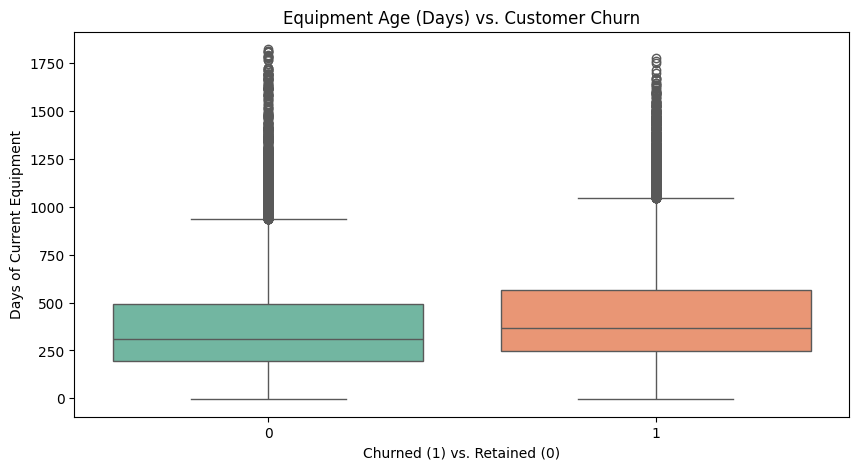

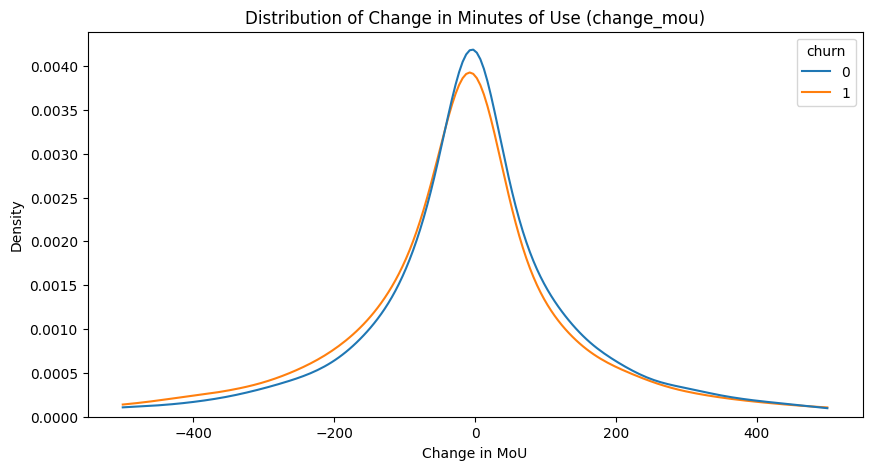

In [3]:
# Cell 4: Churn Distribution
churn_rate = df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.1f}%")

# Cell 5: Visualizing Equipment Days vs Churn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='churn', y='eqpdays', palette='Set2')
plt.title('Equipment Age (Days) vs. Customer Churn')
plt.xlabel('Churned (1) vs. Retained (0)')
plt.ylabel('Days of Current Equipment')
plt.show()

# Cell 6: Visualizing Change in Minutes of Use (change_mou)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='change_mou', hue='churn', common_norm=False, clip=(-500, 500))
plt.title('Distribution of Change in Minutes of Use (change_mou)')
plt.xlabel('Change in MoU')
plt.show()

4. Preprocessing

In [4]:
# Cell 7: Categorical and Missing Value Treatment
# Identify object columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Fill missing values with a string marker to cleanly isolate missingness
    df[col] = df[col].astype(str).fillna('nan')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Fill numeric missing values with medians
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Drop Customer_ID from features so it doesn't leak or throw off the model
X = df.drop(columns=['churn', 'Customer_ID'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

5. Machine Learning Model and Evaluation

Final Model ROC-AUC Score: 0.673


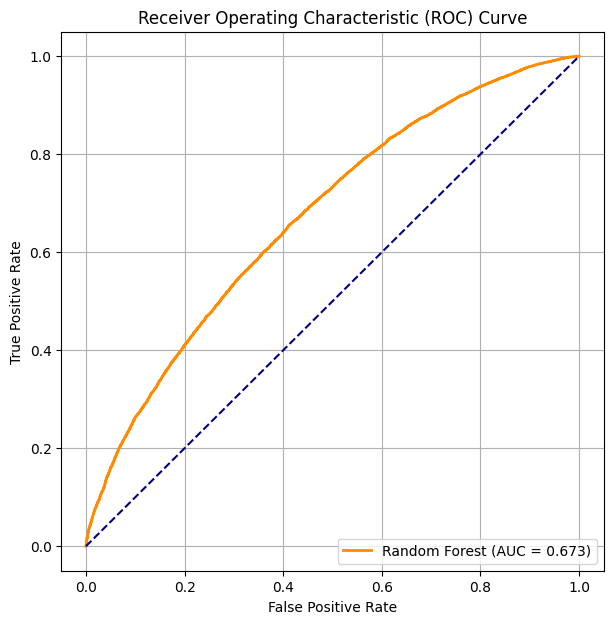

/tmp/ipykernel_2859/2240782296.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:10]], y=X.columns[indices[:10]], palette='viridis')


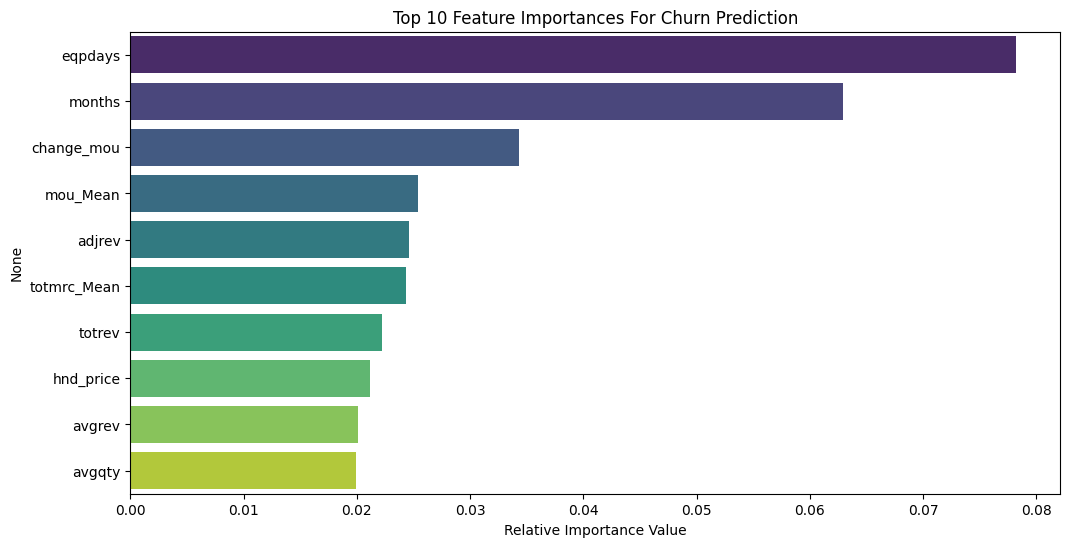

In [5]:
# Cell 8: Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Cell 9: Evaluate Model & Output ROC-AUC Score
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Final Model ROC-AUC Score: {auc_score:.3f}")

# Cell 10: Plot the ROC Curve to mirror slide data
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Cell 11: Extract Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:10]], y=X.columns[indices[:10]], palette='viridis')
plt.title('Top 10 Feature Importances For Churn Prediction')
plt.xlabel('Relative Importance Value')
plt.show()

6. Translating Predictions to Financial Impact

In [6]:
# Cell 11: Business Simulation Code
# Extract average monthly revenue from dataset to confirm your presentation's framework
calculated_avg_rev = df['rev_Mean'].mean()
print(f"Calculated Mean Monthly Revenue from Data: ${calculated_avg_rev:.2f}")

# Simulating Slide 06 Metrics
total_customer_base = 100000
slide_avg_revenue = 58.72
modeled_churn_rate = 0.496

# Expected total churned customers annually without intervention
annual_churned_base = total_customer_base * modeled_churn_rate

# My proposal: Proactive retention system lowers voluntary churn by 15% (Net 10% overall reduction)
churn_reduction_scenario = 0.15
customers_saved = int(annual_churned_base * churn_reduction_scenario)

# Annual financial value calculation (Customers Saved * Average Revenue * 12 Months)
annual_revenue_retained = customers_saved * slide_avg_revenue * 12

print("\n--- PROPOSAL FINANCIAL IMPACT VERIFICATION ---")
print(f"Target Customer Base: {total_customer_base:,} users")
print(f"Assumed Average Monthly Revenue: ${slide_avg_revenue:.2f}")
print(f"Calculated Annual Customers Saved: {customers_saved:,} accounts")
print(f"Quantified Annual Revenue Retained: ${annual_revenue_retained:,.2f}")

Calculated Mean Monthly Revenue from Data: $58.68

--- PROPOSAL FINANCIAL IMPACT VERIFICATION ---
Target Customer Base: 100,000 users
Assumed Average Monthly Revenue: $58.72
Calculated Annual Customers Saved: 7,440 accounts
Quantified Annual Revenue Retained: $5,242,521.60
